# Problem Statement
Customer churn is a major concern for businesses, especially in industries like telecom,
banking, and SaaS. Losing customers leads to revenue loss and increased acquisition costs.
In this project, the goal is to build a Machine Learning classification model that predicts
whether a customer will leave the company (Churn: Yes/No) based on features such as
Customer Age, Gender, Tenure, Monthly Charges, Total Charges, Contract Type,
Payment Method, Internet Service, Tech Support, Online Security, and Customer Support Calls.

In [ ]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# Load Dataset

df = pd.read_csv('telecom_churn_data.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,NaN,Electronic check,70.70,151.65,Yes


In [ ]:
# Check Dataset

df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7038 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7041 non-null   object 


(7043, 21)

In [ ]:
# Handle Missing Values

df.isnull().sum()

# Drop irrelevant column
df.drop(columns=['customerID'], inplace=True)

# TotalCharges may have spaces — convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill numerical with median
for col in df.select_dtypes(include=np.number):
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical with mode
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_13739/4113341866.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_13739/4113341866.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [ ]:
# Remove Duplicate Records

df.drop_duplicates(inplace=True)

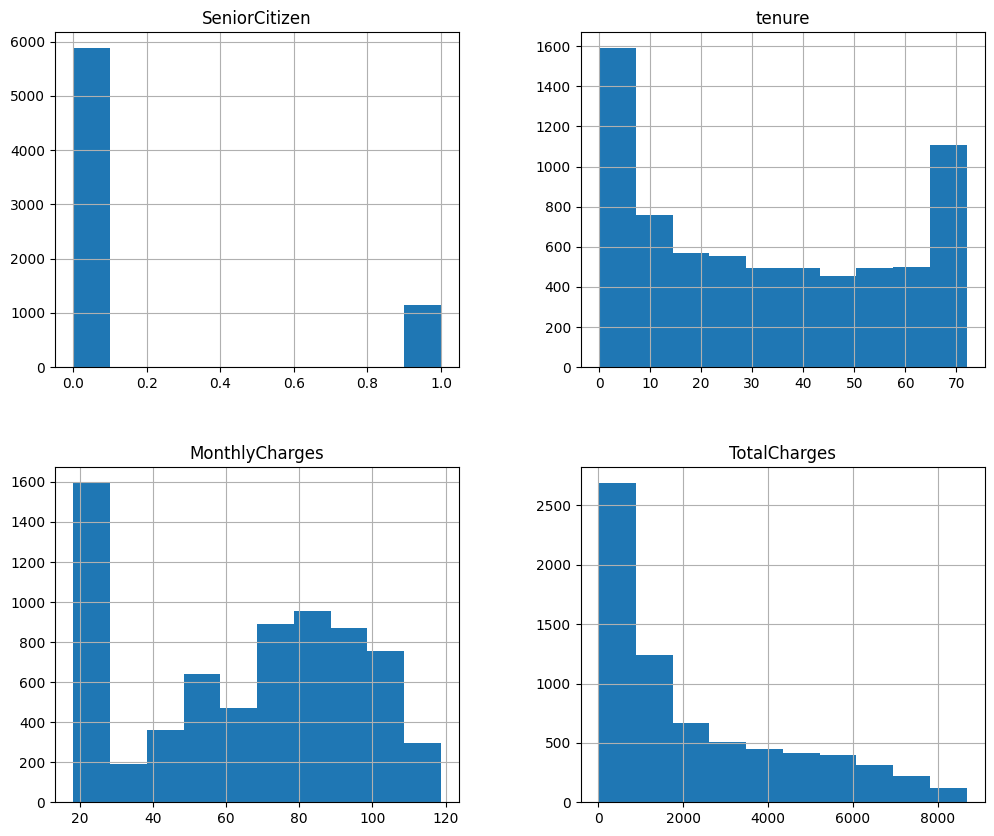

In [ ]:
# Perform Univariate Analysis

df.hist(figsize=(12, 10))
plt.show()

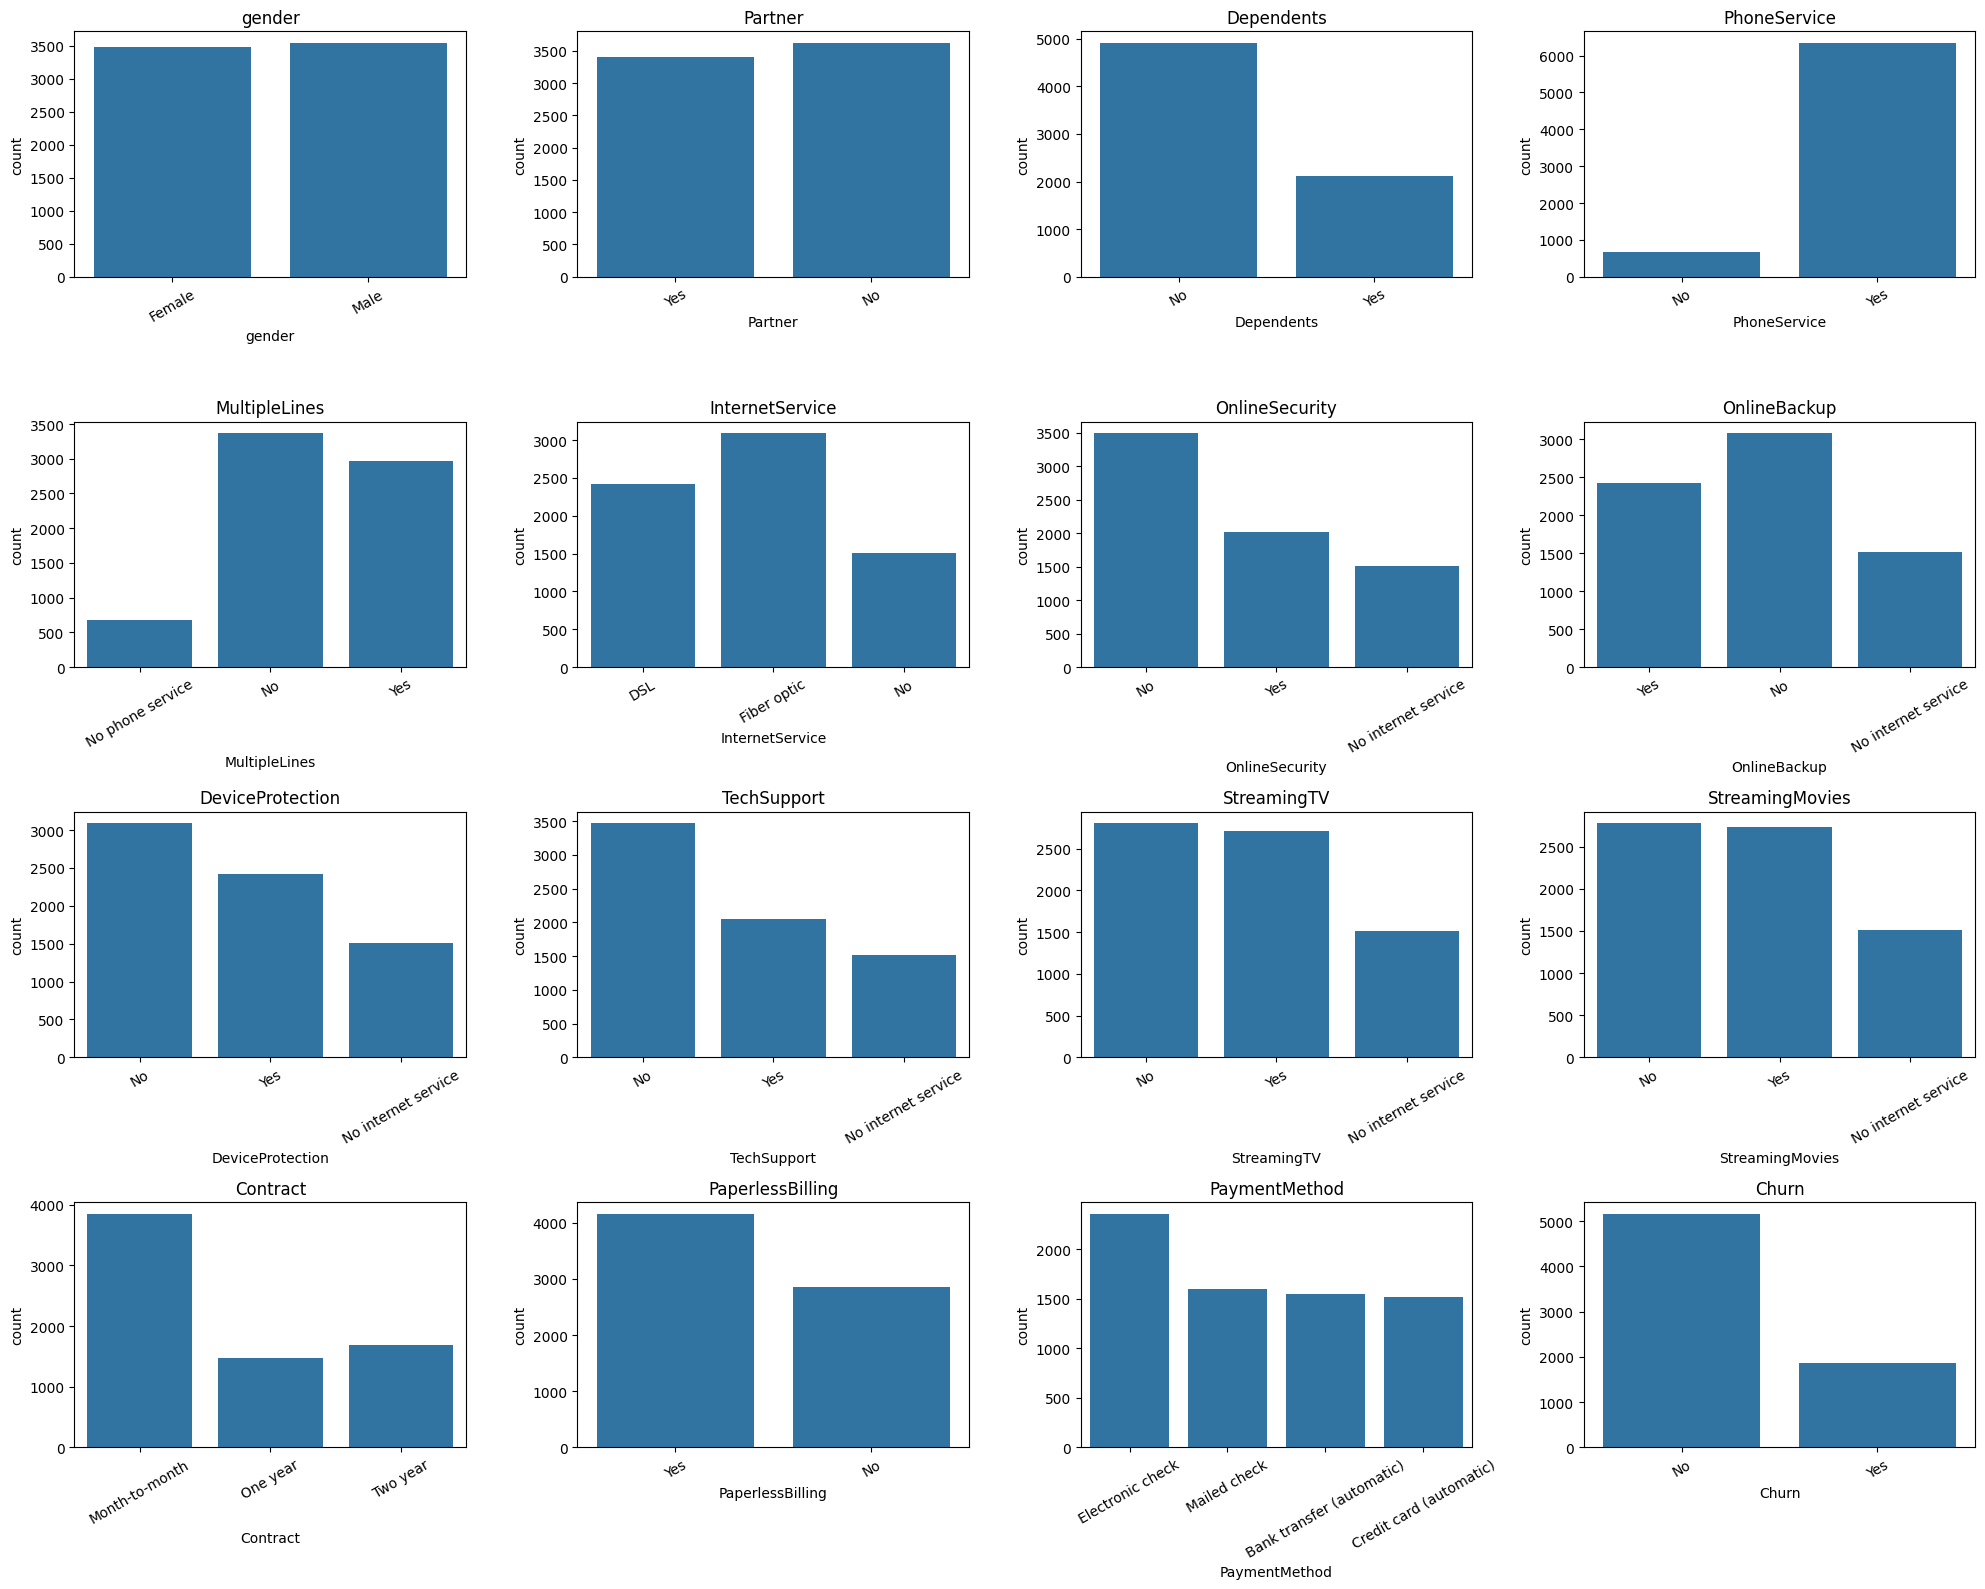

In [ ]:
# Count plots for categorical features

cat_cols = df.select_dtypes(include='object').columns.tolist()

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

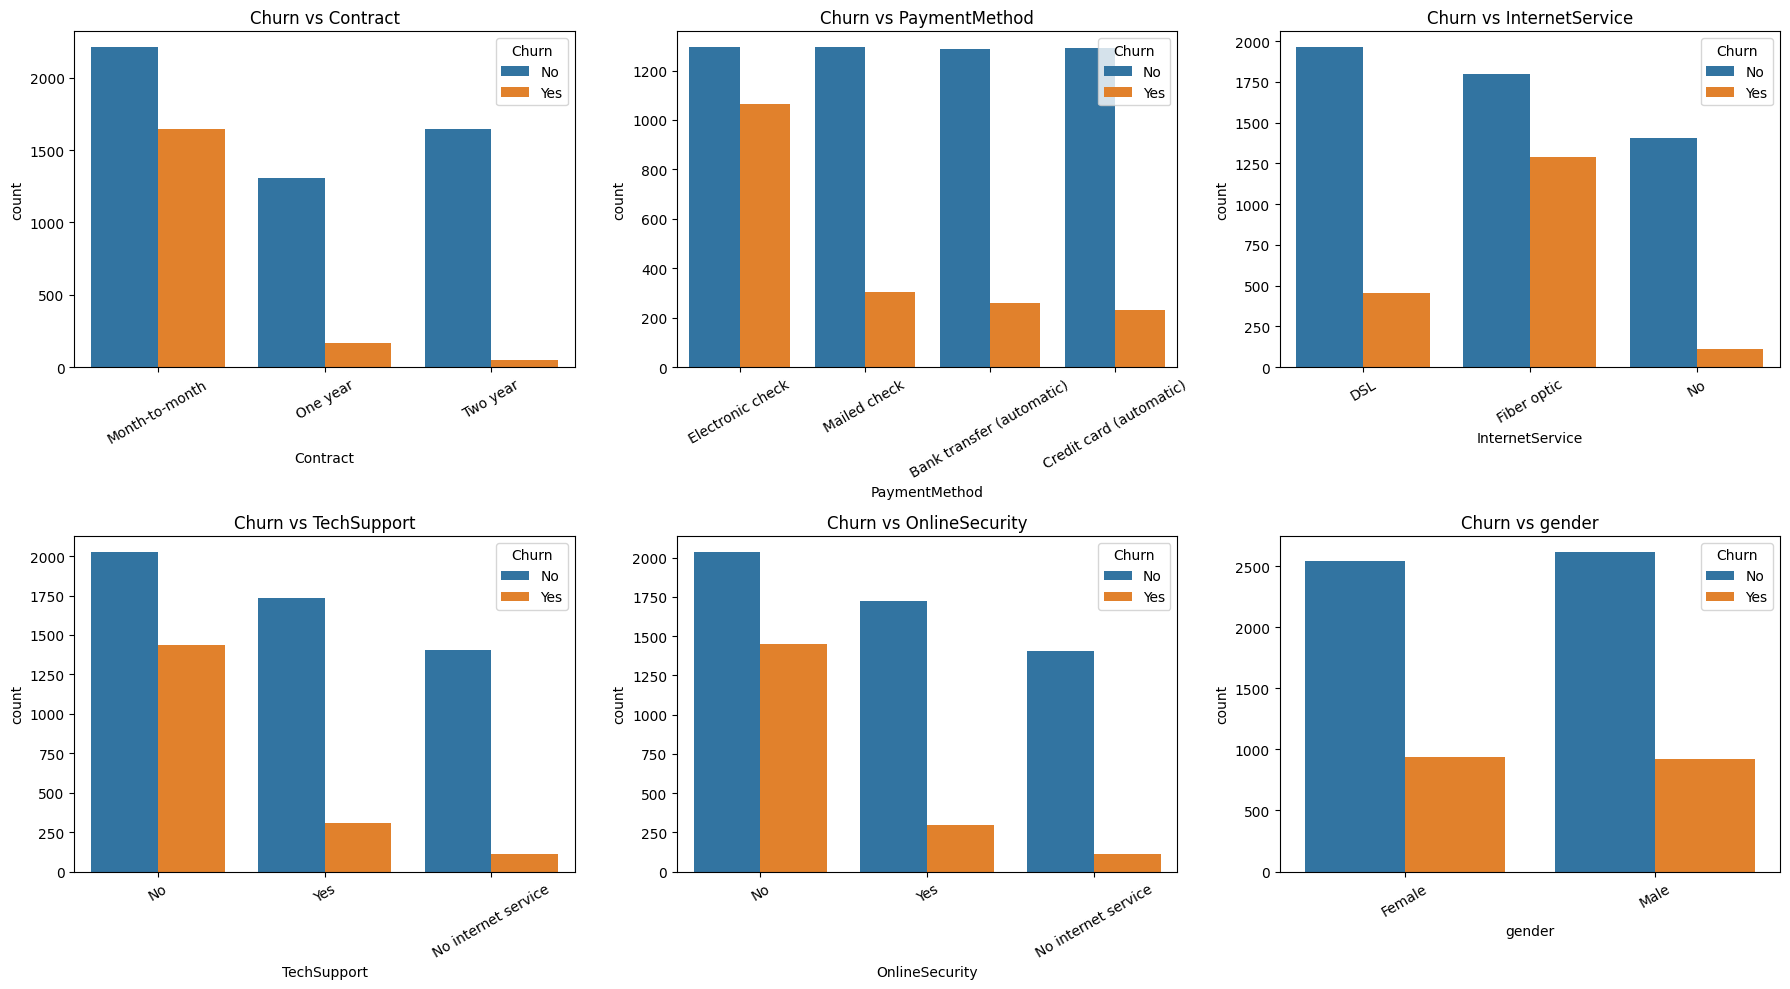

In [ ]:
# Perform Bivariate Analysis
# Churn vs categorical features

cat_features = ['Contract', 'PaymentMethod', 'InternetService', 'TechSupport', 'OnlineSecurity', 'gender']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    sns.countplot(data=df, x=col, hue='Churn', ax=axes[i])
    axes[i].set_title(f'Churn vs {col}')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

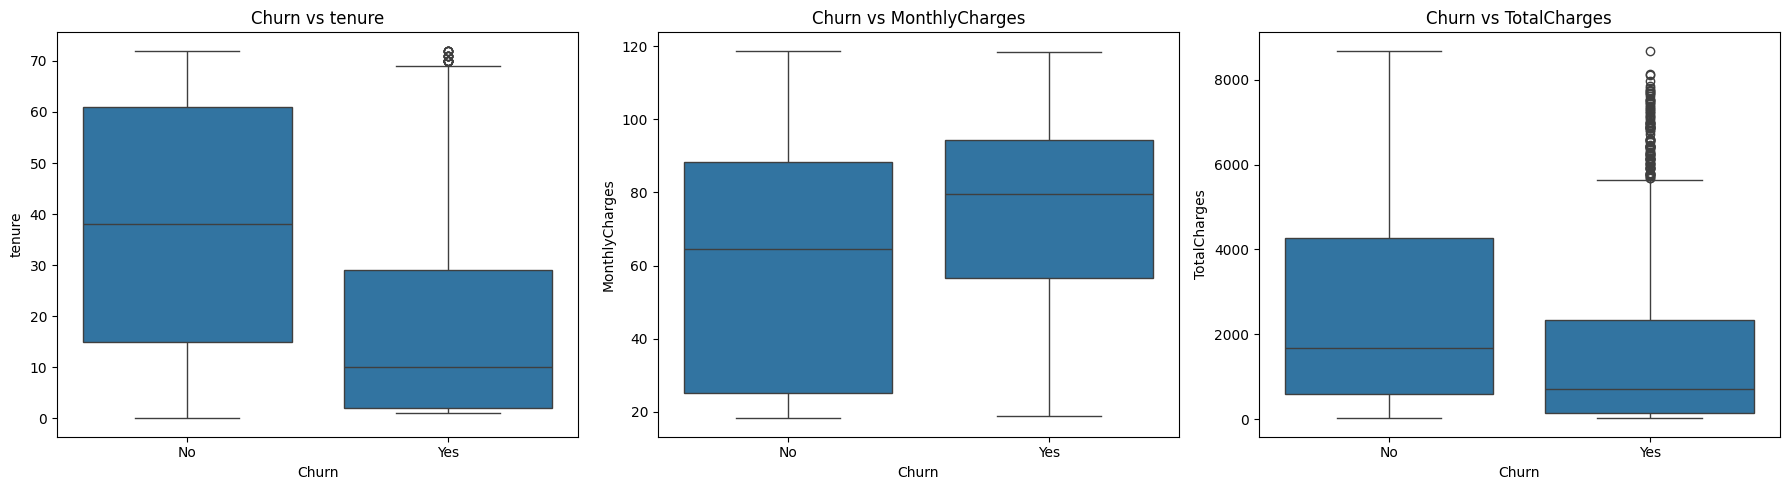

In [ ]:
# Churn vs numerical features

num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_features):
    sns.boxplot(data=df, x='Churn', y=col, ax=axes[i])
    axes[i].set_title(f'Churn vs {col}')

plt.tight_layout()
plt.show()

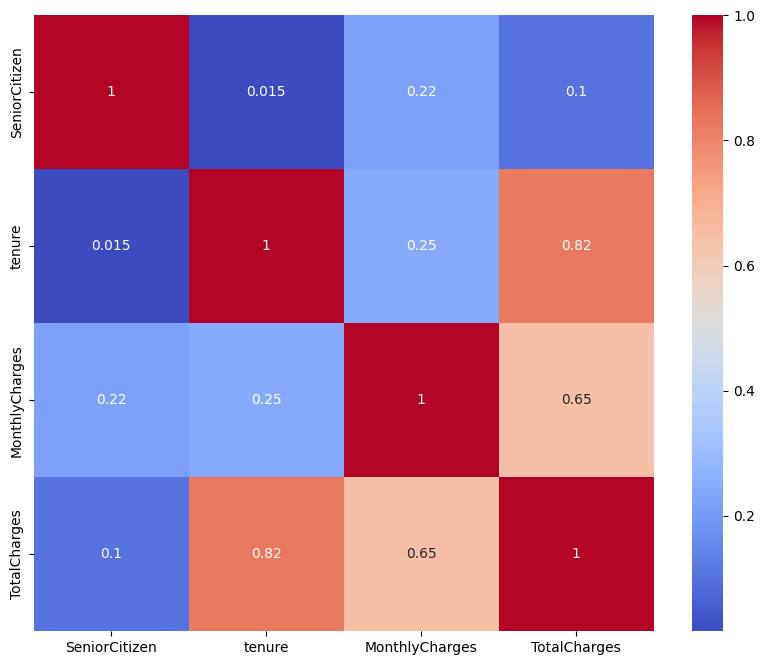

In [ ]:
# Generate Correlation Heatmap

plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
# Detect and Handle Outliers

for col in df.select_dtypes(include=np.number):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

In [ ]:
# Apply Encoding
# Label Encoding

le = LabelEncoder()

label_cols = ['Churn', 'gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in label_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
# One-Hot Encoding

df = pd.get_dummies(df, columns=['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                                 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                                  'Contract', 'PaymentMethod'], drop_first=True)

In [ ]:
# Separate Features and Target Variable

X = df.drop('Churn', axis=1)
y = df['Churn']

In [ ]:
# Perform Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Apply Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Handle Imbalanced Data : SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [ ]:
# Train Classification Models
# Logistic Regression

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [ ]:
# K-Nearest Neighbors (KNN)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

In [ ]:
# Decision Tree Classifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [ ]:
# Random Forest Classifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
# Support Vector Classifier (SVC)

svc = SVC(random_state=42)
svc.fit(X_train, y_train)

y_pred_svc = svc.predict(X_test)

In [ ]:
# Gradient Boosting Classifier

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

In [ ]:
# XGBoost Classifier

xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [ ]:
# Evaluate Models Using Accuracy, Precision, Recall, F1 Score, ROC-AUC Score, Confusion Matrix

def evaluate_model(y_test, y_pred):
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    roc  = roc_auc_score(y_test, y_pred)
    return acc, prec, rec, f1, roc

Logistic Regression:
Accuracy: 0.7587382779198636
Precision: 0.46952595936794583
Recall: 0.8125
F1 Score: 0.5951359084406295
ROC-AUC: 0.7781147764449291


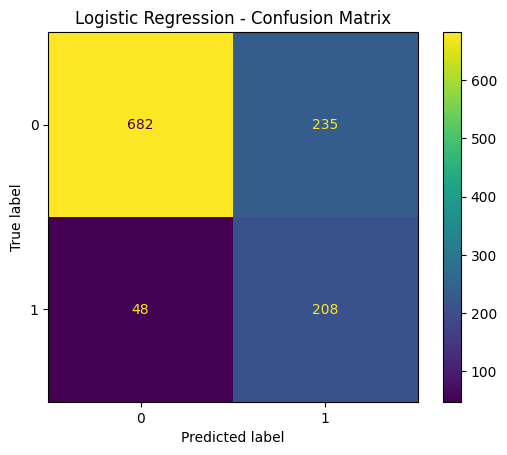

In [ ]:
# Logistic Regression Evaluation

metrics_lr = evaluate_model(y_test, y_pred_lr)

print("Logistic Regression:")
print("Accuracy:", metrics_lr[0])
print("Precision:", metrics_lr[1])
print("Recall:", metrics_lr[2])
print("F1 Score:", metrics_lr[3])
print("ROC-AUC:", metrics_lr[4])

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr)).plot()
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

KNN:
Accuracy: 0.6717817561807332
Precision: 0.36363636363636365
Recall: 0.671875
F1 Score: 0.4718792866941015
ROC-AUC: 0.6718153625954197


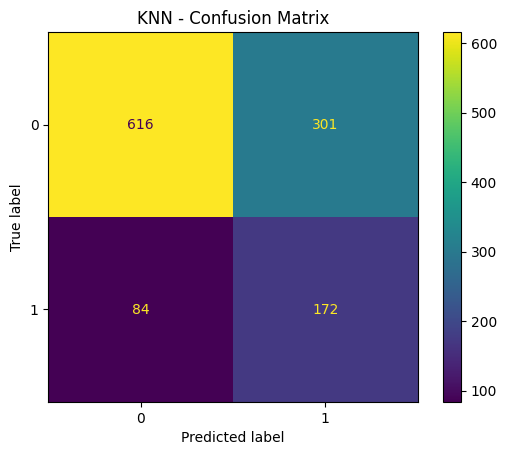

In [ ]:
# KNN Evaluation

metrics_knn = evaluate_model(y_test, y_pred_knn)

print("KNN:")
print("Accuracy:", metrics_knn[0])
print("Precision:", metrics_knn[1])
print("Recall:", metrics_knn[2])
print("F1 Score:", metrics_knn[3])
print("ROC-AUC:", metrics_knn[4])

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_knn)).plot()
plt.title('KNN - Confusion Matrix')
plt.show()

Decision Tree:
Accuracy: 0.7450980392156863
Precision: 0.4383954154727794
Recall: 0.59765625
F1 Score: 0.5057851239669422
ROC-AUC: 0.6919578959923665


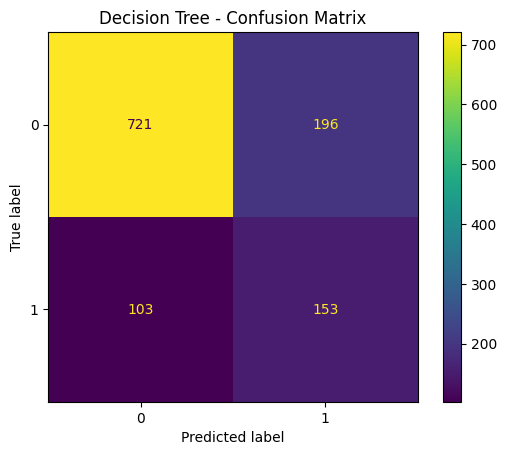

In [ ]:
# Decision Tree Evaluation

metrics_dt = evaluate_model(y_test, y_pred_dt)

print("Decision Tree:")
print("Accuracy:", metrics_dt[0])
print("Precision:", metrics_dt[1])
print("Recall:", metrics_dt[2])
print("F1 Score:", metrics_dt[3])
print("ROC-AUC:", metrics_dt[4])

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_dt)).plot()
plt.title('Decision Tree - Confusion Matrix')
plt.show()

Random Forest:
Accuracy: 0.8107416879795396
Precision: 0.5634328358208955
Recall: 0.58984375
F1 Score: 0.5763358778625954
ROC-AUC: 0.7311268913576882


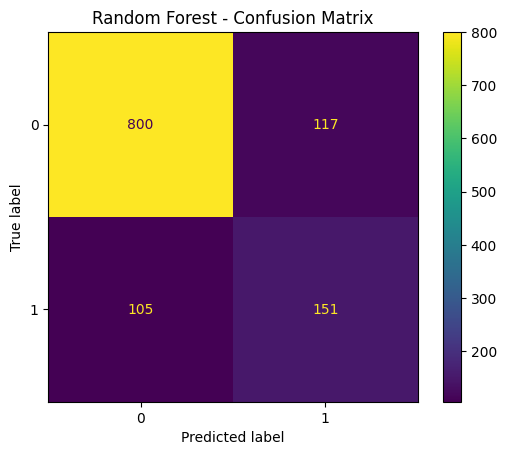

In [ ]:
# Random Forest Evaluation

metrics_rf = evaluate_model(y_test, y_pred_rf)

print("Random Forest:")
print("Accuracy:", metrics_rf[0])
print("Precision:", metrics_rf[1])
print("Recall:", metrics_rf[2])
print("F1 Score:", metrics_rf[3])
print("ROC-AUC:", metrics_rf[4])

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf)).plot()
plt.title('Random Forest - Confusion Matrix')
plt.show()

Support Vector Classifier:
Accuracy: 0.7578857630008525
Precision: 0.46335078534031415
Recall: 0.69140625
F1 Score: 0.554858934169279
ROC-AUC: 0.7339255895583424


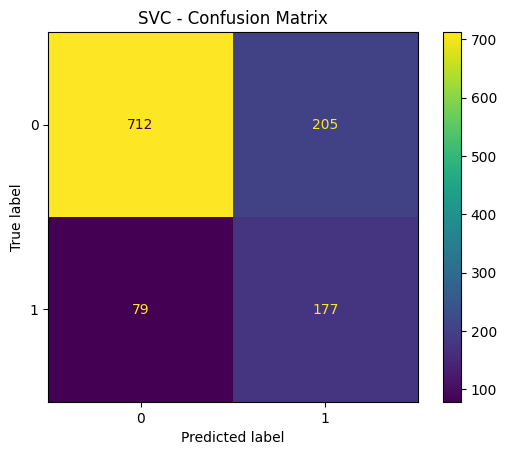

In [ ]:
# SVC Evaluation

metrics_svc = evaluate_model(y_test, y_pred_svc)

print("Support Vector Classifier:")
print("Accuracy:", metrics_svc[0])
print("Precision:", metrics_svc[1])
print("Recall:", metrics_svc[2])
print("F1 Score:", metrics_svc[3])
print("ROC-AUC:", metrics_svc[4])

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_svc)).plot()
plt.title('SVC - Confusion Matrix')
plt.show()

Gradient Boosting:
Accuracy: 0.7971014492753623
Precision: 0.5274390243902439
Recall: 0.67578125
F1 Score: 0.5924657534246576
ROC-AUC: 0.7533759030806979


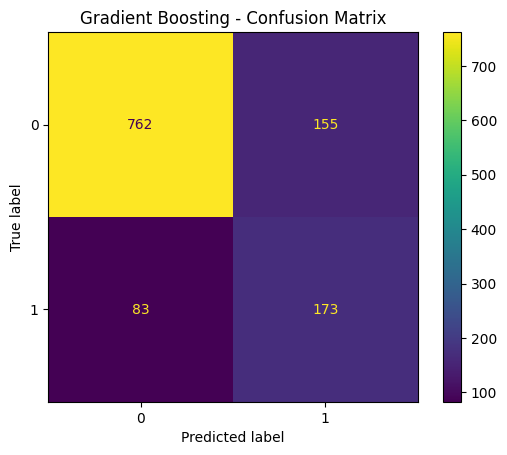

In [ ]:
# Gradient Boosting Evaluation

metrics_gb = evaluate_model(y_test, y_pred_gb)

print("Gradient Boosting:")
print("Accuracy:", metrics_gb[0])
print("Precision:", metrics_gb[1])
print("Recall:", metrics_gb[2])
print("F1 Score:", metrics_gb[3])
print("ROC-AUC:", metrics_gb[4])

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_gb)).plot()
plt.title('Gradient Boosting - Confusion Matrix')
plt.show()

XGBoost:
Accuracy: 0.7928388746803069
Precision: 0.5231316725978647
Recall: 0.57421875
F1 Score: 0.547486033519553
ROC-AUC: 0.7140450347600872


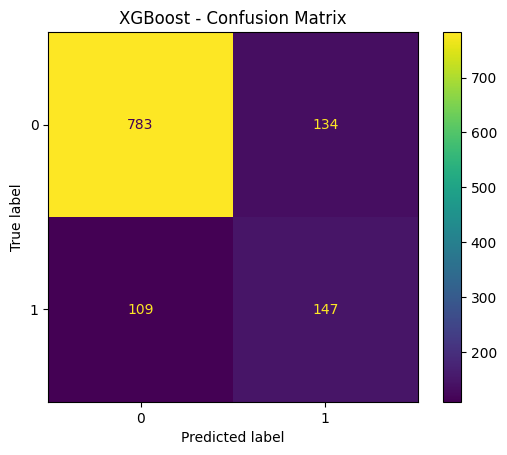

In [ ]:
# XGBoost Evaluation

metrics_xgb = evaluate_model(y_test, y_pred_xgb)

print("XGBoost:")
print("Accuracy:", metrics_xgb[0])
print("Precision:", metrics_xgb[1])
print("Recall:", metrics_xgb[2])
print("F1 Score:", metrics_xgb[3])
print("ROC-AUC:", metrics_xgb[4])

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_xgb)).plot()
plt.title('XGBoost - Confusion Matrix')
plt.show()

In [ ]:
# Hyperparameter Tuning
# GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score:", grid_search.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best F1 Score: 0.854901087710993


In [ ]:
# RandomizedSearchCV

from scipy.stats import randint

param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': randint(2, 10)
}

rand_search = RandomizedSearchCV(XGBClassifier(random_state=42, eval_metric='logloss'), param_dist, n_iter=20, cv=3, scoring='f1', random_state=42)
rand_search.fit(X_train, y_train)

print("Best Parameters:", rand_search.best_params_)
print("Best F1 Score:", rand_search.best_score_)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:27:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:27:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:27:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:27:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Best Parameters: {'max_depth': 20, 'min_samples_split': 8, 'n_estimators': 171}
Best F1 Score: 0.8135774651009954


In [ ]:
# Compare Model Performance

comparison = pd.DataFrame({
    'Model':     ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'SVC', 'Gradient Boosting', 'XGBoost'],
    'Accuracy':  [metrics_lr[0], metrics_knn[0], metrics_dt[0], metrics_rf[0], metrics_svc[0], metrics_gb[0], metrics_xgb[0]],
    'Precision': [metrics_lr[1], metrics_knn[1], metrics_dt[1], metrics_rf[1], metrics_svc[1], metrics_gb[1], metrics_xgb[1]],
    'Recall':    [metrics_lr[2], metrics_knn[2], metrics_dt[2], metrics_rf[2], metrics_svc[2], metrics_gb[2], metrics_xgb[2]],
    'F1 Score':  [metrics_lr[3], metrics_knn[3], metrics_dt[3], metrics_rf[3], metrics_svc[3], metrics_gb[3], metrics_xgb[3]],
    'ROC-AUC':   [metrics_lr[4], metrics_knn[4], metrics_dt[4], metrics_rf[4], metrics_svc[4], metrics_gb[4], metrics_xgb[4]]
})

print(comparison)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.758738   0.469526  0.812500  0.595136  0.778115
1                  KNN  0.671782   0.363636  0.671875  0.471879  0.671815
2        Decision Tree  0.745098   0.438395  0.597656  0.505785  0.691958
3        Random Forest  0.810742   0.563433  0.589844  0.576336  0.731127
4                  SVC  0.757886   0.463351  0.691406  0.554859  0.733926
5    Gradient Boosting  0.797101   0.527439  0.675781  0.592466  0.753376
6              XGBoost  0.792839   0.523132  0.574219  0.547486  0.714045


In [ ]:
# Select Best Model

best_model = comparison.loc[comparison['F1 Score'].idxmax(), 'Model']
print("Best Model based on F1 Score:", best_model)

Best Model based on F1 Score: Logistic Regression


In [ ]:
import pickle

# Assuming 'lr' is your best Logistic Regression model and 'scaler' is your StandardScaler
# Save the best model (Logistic Regression)
with open('model.pkl', 'wb') as f:
    pickle.dump(lr, f)

# Save the scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model and scaler saved successfully using pickle!")

Model and scaler saved successfully using pickle!


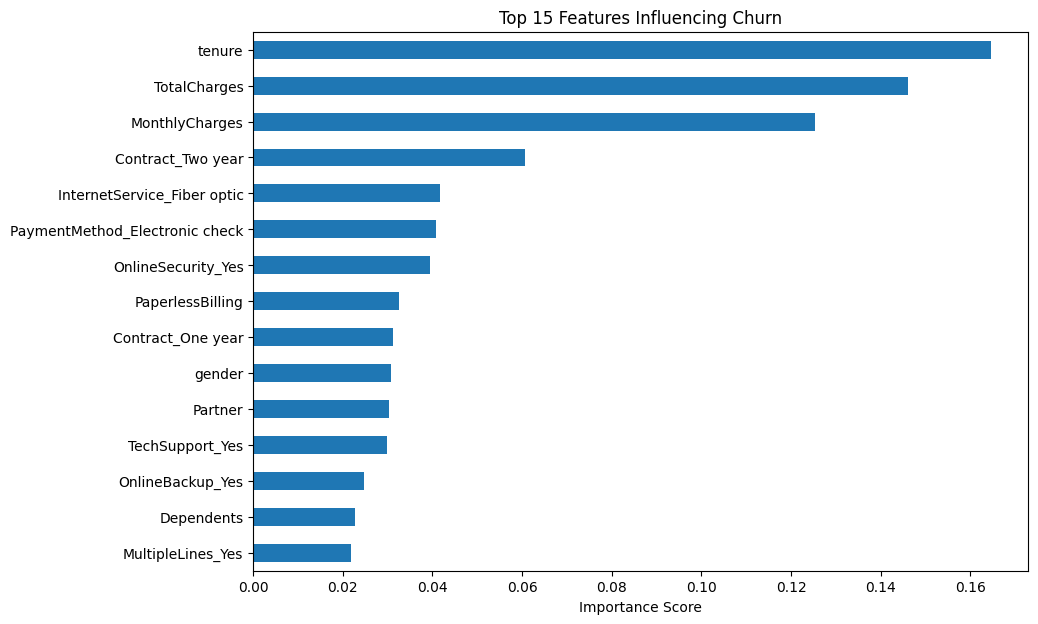

In [ ]:
# Final Insights
# Key factors influencing churn

best_rf = grid_search.best_estimator_
feature_names = df.drop('Churn', axis=1).columns

importances = pd.Series(best_rf.feature_importances_, index=feature_names)
top15 = importances.nlargest(15)

top15.sort_values().plot(kind='barh', figsize=(10, 7))
plt.title('Top 15 Features Influencing Churn')
plt.xlabel('Importance Score')
plt.show()

In [ ]:
# Business Recommendations

'''
Key Factors Influencing Churn:
1. MonthlyCharges   - High monthly charges lead to higher churn.
2. Contract         - Month-to-month contracts have the highest churn rate.
3. TechSupport      - Customers without tech support churn more.
4. tenure           - Short tenure customers are more likely to churn.
5. OnlineSecurity   - Customers without online security churn more.

Business Recommendations:
1. Offer long-term contract discounts to reduce month-to-month churn.
2. Improve customer support services and tech support availability.
3. Provide personalized retention offers for high-risk customers.
4. Identify high-risk customers early using the trained ML model.
5. Reduce churn through loyalty programs and rewards.
'''

'\nKey Factors Influencing Churn:\n1. MonthlyCharges   - High monthly charges lead to higher churn.\n2. Contract         - Month-to-month contracts have the highest churn rate.\n3. TechSupport      - Customers without tech support churn more.\n4. tenure           - Short tenure customers are more likely to churn.\n5. OnlineSecurity   - Customers without online security churn more.\n\nBusiness Recommendations:\n1. Offer long-term contract discounts to reduce month-to-month churn.\n2. Improve customer support services and tech support availability.\n3. Provide personalized retention offers for high-risk customers.\n4. Identify high-risk customers early using the trained ML model.\n5. Reduce churn through loyalty programs and rewards.\n'